In [1]:
import numpy as np              # load numerical module
import matplotlib.pyplot as plt # load plotting module
import astropy.io.fits as fits  # get FITS 
import pandas as pd             # get pandas 

from astropy.modeling.models import BlackBody  #get the astropy BB method
from astropy import units as u                 #also get the units

import os                       #import os module

### An overview/recap of terms we see in the class:

- object/target : what you're taking a picture of, usually something in the sky
- integration or exposure time : the amount of time light from the target falls on an array
- FITS file : Flexible Image Transport System, a data file format where data are in binary format
    - mainly used for images with 1 HDU = header-data unit = 1 header + 1 dataset
    - Header documents origin of image, what has been done to it
- image stack or image cube : a 3D array of images laid "on top" of each other like pages in a book

### and some Python stuff:
- pandas:"a fast, powerful, flexible and easy to use open source data analysis and manipulation tool"
    - built on top of numpy
    - use labels of columns to ID them (e.g., exo_data['mass'] gets you the data contained in column 'mass')
    - can easily read data with gaps in them
    - can easily filter data to remove NaNs/gaps etc
    
- astropy https://www.astropy.org/ : the astronomical Python package
    
- broadcast (Python):
    - operating on arrays with different but "compatible" shapes
    - the smaller array is missing dimensions of the larger array
    - the smaller array is repeated to fill in the missing dimensions
    - this is a critical NumPy concept!
    - *redo NumPy tutorial if not familiar* (https://www.tutorialspoint.com/numpy/numpy_broadcasting.html, https://numpy.org/doc/stable/user/basics.broadcasting.html)
    


## Coding a data analysis

### So, you finally got that precious data from your succesful JWST GO program or you found a treasure trove no one had exploited todate in the telescopes' archives (MAST: https://archive.stsci.edu/, KOA: https://www2.keck.hawaii.edu/koa/public/koa.php, ESO:http://archive.eso.org/cms.html  etc). What now? 

### How do you get from the raw data to the science you are after?

### Overall, the flow you need to follow is very similar to the flow you should follow when writting a *good* or *great* proposal:

### -------

<img src="hypothesis_generation.png" width=300 height=300 /> (source: xkcd comics)


### The good proposal path: <br> 

- Start with the question you have in mind/your science goal 
- Think of why this is an important question to your field and be able to explain it to your peers in the panel 
- What are the steps you need to take to accomplish your goal (identify tasks you need to follow)

<br>

- Think: 
    - how will you get to accomplish those steps (what are the observations/data analysis you need?)
        - are there particular tests you can do to separate different scenarios?
        - are there degeneracies from other observations that your new proposed data/method will fix?
        
    - what are the issues you might face in the process? 
        - do you have a mitigation plan?
        - if not possible, how does that affect your science?


### -------    

### Think- Pair- Share (10+5 min):

### Let's work with this test case: 
- Science Question: Is the Moon made of cheese?
    - Why is this important to figure out?
        - what are possible competing ideas about the Moon?
    - How can you figure out which idea is right? 
        - identify steps you need to take 
            - are there particular tests you can do to separate ideas?
            - are there degeneracies/ possible problems that might show up? how do you fix them?
  
  
### -------    

### Very similar path for coding your data analysis:

- Begin with the end in mind and plan ("science flowdown"):
    - What is my science goal? 
        - of course, ideally, this is something you already know when getting your data
    - What is the argument that supports my science goal? 
        - if data are from your proposal you already have this thought of
    - What evidence supports my argument? 
        - same as before
    
    - What plots, tables, and images will present my evidence? 

- Plan the major steps and intermediate data products to get them
    - If your data in new
        - clean raw data from CR/ tellurics/ systematics/ etc (as applicable)
            - often, you will go after the same instruments; this might be done using the same functions/ pipe line
            - remember: don't reinvent the wheel!

    - Figure out what calculations you will do 
        - often make functions as you need to repeatedly do same thing for *many* plots/data
        - are there models you need to fit your data with? collect them
        - CODE!
        
        
       
#### Final note: often your data will take you down unexpected paths 
    - things will not be as you imagined
    - data might have interesting new surprises
    - learn to appreciate the twists, they might land you your next Science/Nature paper
        

### A few rules you should always keep in mind:

- Data are sacred, you should never run an analysis in the data directory.
    - If file numbering gets messed up, file times reveal true creation order
    - Some programs will modify files just by looking at them!
    - Many programs write files locally, changing directory timestamp

- You should always separate analysis from data!
    - Keeps your data intact
    - You can track updates to your data analysis independently ( Git(Hub) )


- Use top-level files with all commands specific to your analysis
- Write general routines/functions called by those specific files
- Multiple files?  Big waits?
 - Put saves after big CPU waits, then break files after saves
 
- Pass or compute values like sizes that vary from one analysis to another.  **Don't *ever* hard-code**.


### Software Implementation: 
- Good data reduction pipelines follow our homework format
    - Look at notebook solutions to see how to break out values from code
- Dated log file has notes and commands tested (not distributed)
- File(s) of naked commands or high-level functions
  - Have things specific to data
  - Define order of what happens to data
  - Can be batch-run as Unix command
- General routines get called from batch file


- Use strings to list files; do not iterate over numbers and insert into rootname unless certain there are no bad frames 
    - of course, remember that you can use Python structures to avoid code crashing if you need to do this
    - allows you to eliminate bad files in list easily
   
   
- Separate directory-name and FITS extension strings make it easy to insert substrings in output filenames

In [2]:
# Embedding numbers into strings with formatting
# https://realpython.com/python-string-formatting/

datapath = "/path/to/data" # things that need adjusting from user stay at top (or asked as input)
fileroot = "stars_13s_"    
fext     = ".fits"

print("Old-style string formatting:")
# Familiar from C, but don't learn if you don't know it already.
# uses a '%' sign between the string and values to substitute
for filenum in range(8,12):
  file = "%s/%s%04d%s" % (datapath, fileroot, filenum, fext)
  print(file)

print("New-style string formatting:")
# uses .format() between string and values (it's a method of the string class)
for filenum in range(8,12):
  file = "{}/{}{:04d}{}".format(datapath, fileroot, filenum, fext)
  print(file)

print("Literal string interpolation:")
# Variables apper in string, best if using Python 3.6 or later
for filenum in range(8,12):
  file = f"{datapath}/{fileroot}{filenum:04d}{fext}"
  print(file)

# The format codes are mostly the same!
# %s, %f, %d, etc. become {}...no need to tell it the type, it knows!
# %10s, %03.9f, %04d, etc., become {:10s}, {:03.9f}, {:04d} in new-style and literal interpolation
# in literal interpolation, the variable comes before the colon: {filenum:04d}
#
# the three type specifiers to know: s = string, f = float, d = decimal integer
# the three format specifiers to know:
# a number {:4d}: makes the field this wide, padded with spaces 
# 0 and a number {:04d}: makes the field this wide, padded with zeros
# a number, decimal, a number (:12.3f): the field is as wide as the first number, with decimal precision of the second

Old-style string formatting:
/path/to/data/stars_13s_0008.fits
/path/to/data/stars_13s_0009.fits
/path/to/data/stars_13s_0010.fits
/path/to/data/stars_13s_0011.fits
New-style string formatting:
/path/to/data/stars_13s_0008.fits
/path/to/data/stars_13s_0009.fits
/path/to/data/stars_13s_0010.fits
/path/to/data/stars_13s_0011.fits
Literal string interpolation:
/path/to/data/stars_13s_0008.fits
/path/to/data/stars_13s_0009.fits
/path/to/data/stars_13s_0010.fits
/path/to/data/stars_13s_0011.fits


In [3]:
#Remember that if you need to iterate over files there are a few ways to do that:

#1. use your OS to list and open the files:
moke_data = os.listdir('moke_dir_listing/')

#loop over the files and do sth with them:
for nm in range( len( moke_data ) ):
    
    print( moke_data[ nm ] )
    #typically here you would open the data, do stuff with it....

exampledark4.fits
exampledark2.fits
exampleflat.fits
exampledark1.fits


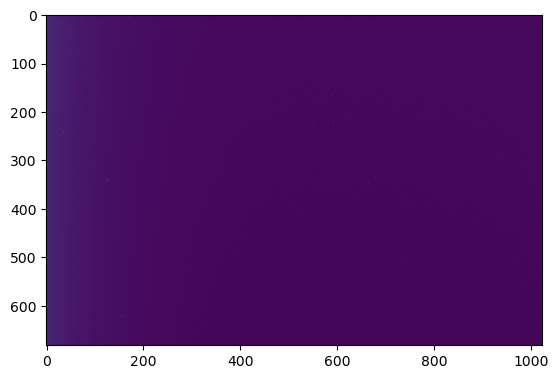

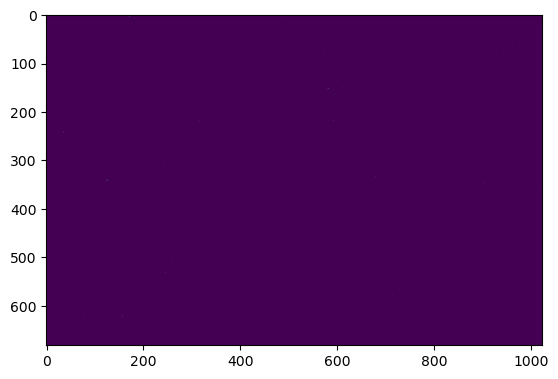

File: moke_dir_listing/exampledark3.fits not there or corrupt!


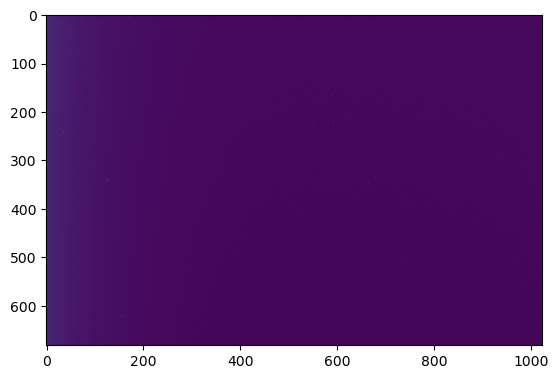

In [4]:
#2. If you want to loop over files with given name format 
# you can also use Python's try method:

datapath = "moke_dir_listing" # things that need adjusting from user stay at top (or asked as input)
fileroot = "exampledark"    
fext     = ".fits"



for num in range(1,5):
    file = "{}/{}{:1d}{}".format(datapath, fileroot, num, fext)

    #now we want to open and read the file, BUT not have it crash if not there or corrupt:
    
    try:
        im = fits.getdata( file )
        plt.imshow( im )
        plt.show()
        
    except:
        print('File:', file ,'not there or corrupt!')
        

### Think-Pair-Share (25min)

### File ross458c_fits contains a couple of FITS files from exoplanet Ross 458c observed with HST. These files are *raw*. To see the data you can start by plotting them (imshow). Play around with the scaling. You can see a few things in the images: astrophysical targets, but also a number of extra features. Some are detector flaws, some are CR. Now read the data in your code and plot the different frames with some scaling (e.g., log) to see how the images change here. Use this small dataset to make a cleaner observation. What do you think about the features that are left in the final image?

-With thanks to B. Lew (NASA BAERI) for providing the data

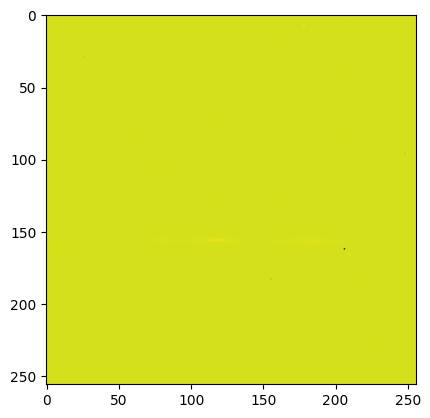

In [44]:
path = r'C:\Users\Alex\Desktop\AST5765\lectures_git\lectures_week7\ross458c_fits\icytp1k5q_flt.fits'
image = fits.getdata(path)
plt.imshow(image)

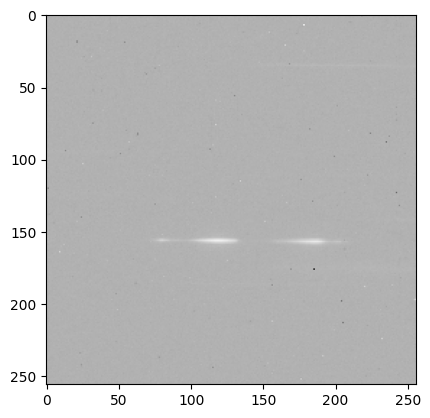

In [45]:
plt.imshow( 100 * np.log10(np.where( image > 0, image, 1)), cmap='grey')

In [58]:
x1, y1 = np.shape(image)

# Instead o 9 would want len of array
fileloc = r'C:\Users\Alex\Desktop\AST5765\lectures_git\lectures_week7\ross458c_fits\ '
list = os.listdir(fileloc)

image_cube = np.zeros( (len(list), x1, y1))

for nm in range(len(list)):
    im = fits.getdata(fileloc + list[nm])
    image_cube[nm, :, :] = im

FileNotFoundError: [WinError 3] The system cannot find the path specified: 'C:\\Users\\Alex\\Desktop\\AST5765\\lectures_git\\lectures_week7\\ross458c_fits\\ '

### Think-Pair-Share (25 min)

### Assume you build a 2048x2048 CCD that you want to use to observe a star. The star's location on the CCD is in the top left corn at pixel (30, 10). The readout happens after the bottom row (2048,*). During an integration time of 10s we got 1e5 photons from the star. The CCD has a QE of 99.995%. Assuming no background noise and a gain of 10 e−/ADU, how many ADUs are recorded at the end? What is the SNR of our detection?

In [28]:
xall = 2048
yall = 2048

xin = 30
yin = 30

Nin = 1e5
QE = 0.99995
CTE = QE
gain = 10

Nstart = QE * Nin
for i in range( (yall-yin) + (xall - xin)):
    Nstart *= CTE

print(Nstart)

81721.33773633403


In [30]:
# ADU recodred
# gain of 10 e- per ADU

ADU = Nstart / gain

SNR = np.sqrt(Nstart)


In [29]:
y = 2028

CCD = np.zeros(4194304).reshape(2048, 2048)

# pixel = 

# Have a pixel at location (30,10)

t        = 10 # sec
pho_star = 1e5 
back     = 10 # e-/ADU

QE = 0.99995

CCD[(30, 10)] = pho_star

In [25]:
N = CCD
for i in range(y):
    N *= QE

print(N[(30,10)])

66656.99855245724
